In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Create Internship Funnel Dataset
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    'Applicant_ID': range(1, n+1),
    'Age': np.random.randint(18, 30, n),
    'Gender': np.random.choice(['Male', 'Female'], n),
    'Field': np.random.choice(['Data Science', 'Marketing', 'Design', 'Development', 'HR'], n),
    'Experience_Months': np.random.randint(0, 24, n),
    'Applied': 1,
    'Shortlisted': np.random.choice([0,1], n, p=[0.6, 0.4]),
    'Interviewed': np.random.choice([0,1], n, p=[0.7, 0.3]),
    'Selected': np.random.choice([0,1], n, p=[0.8, 0.2]),
    'Joined': np.random.choice([0,1], n, p=[0.85, 0.15]),
})

print(" Dataset created!")
print(f"Total Applicants: {len(df)}")
print(df.head())

 Dataset created!
Total Applicants: 1000
   Applicant_ID  Age  Gender        Field  Experience_Months  Applied  \
0             1   24  Female           HR                 15        1   
1             2   21  Female           HR                  4        1   
2             3   28  Female  Development                 19        1   
3             4   25    Male    Marketing                  9        1   
4             5   22  Female           HR                 17        1   

   Shortlisted  Interviewed  Selected  Joined  
0            0            1         0       0  
1            0            0         0       0  
2            1            1         0       0  
3            1            0         0       0  
4            0            0         1       0  


In [2]:
applied = df['Applied'].sum()
shortlisted = df['Shortlisted'].sum()
interviewed = df['Interviewed'].sum()
selected = df['Selected'].sum()
joined = df['Joined'].sum()

print("====== FUNNEL KPIs ======")
print(f" Total Applied:      {applied}")
print(f" Shortlisted:        {shortlisted} ({shortlisted/applied*100:.1f}%)")
print(f" Interviewed:        {interviewed} ({interviewed/applied*100:.1f}%)")
print(f" Selected:           {selected} ({selected/applied*100:.1f}%)")
print(f" Joined:             {joined} ({joined/applied*100:.1f}%)")

====== FUNNEL KPIs ======
 Total Applied:      1000
 Shortlisted:        406 (40.6%)
 Interviewed:        269 (26.9%)
 Selected:           205 (20.5%)
 Joined:             147 (14.7%)


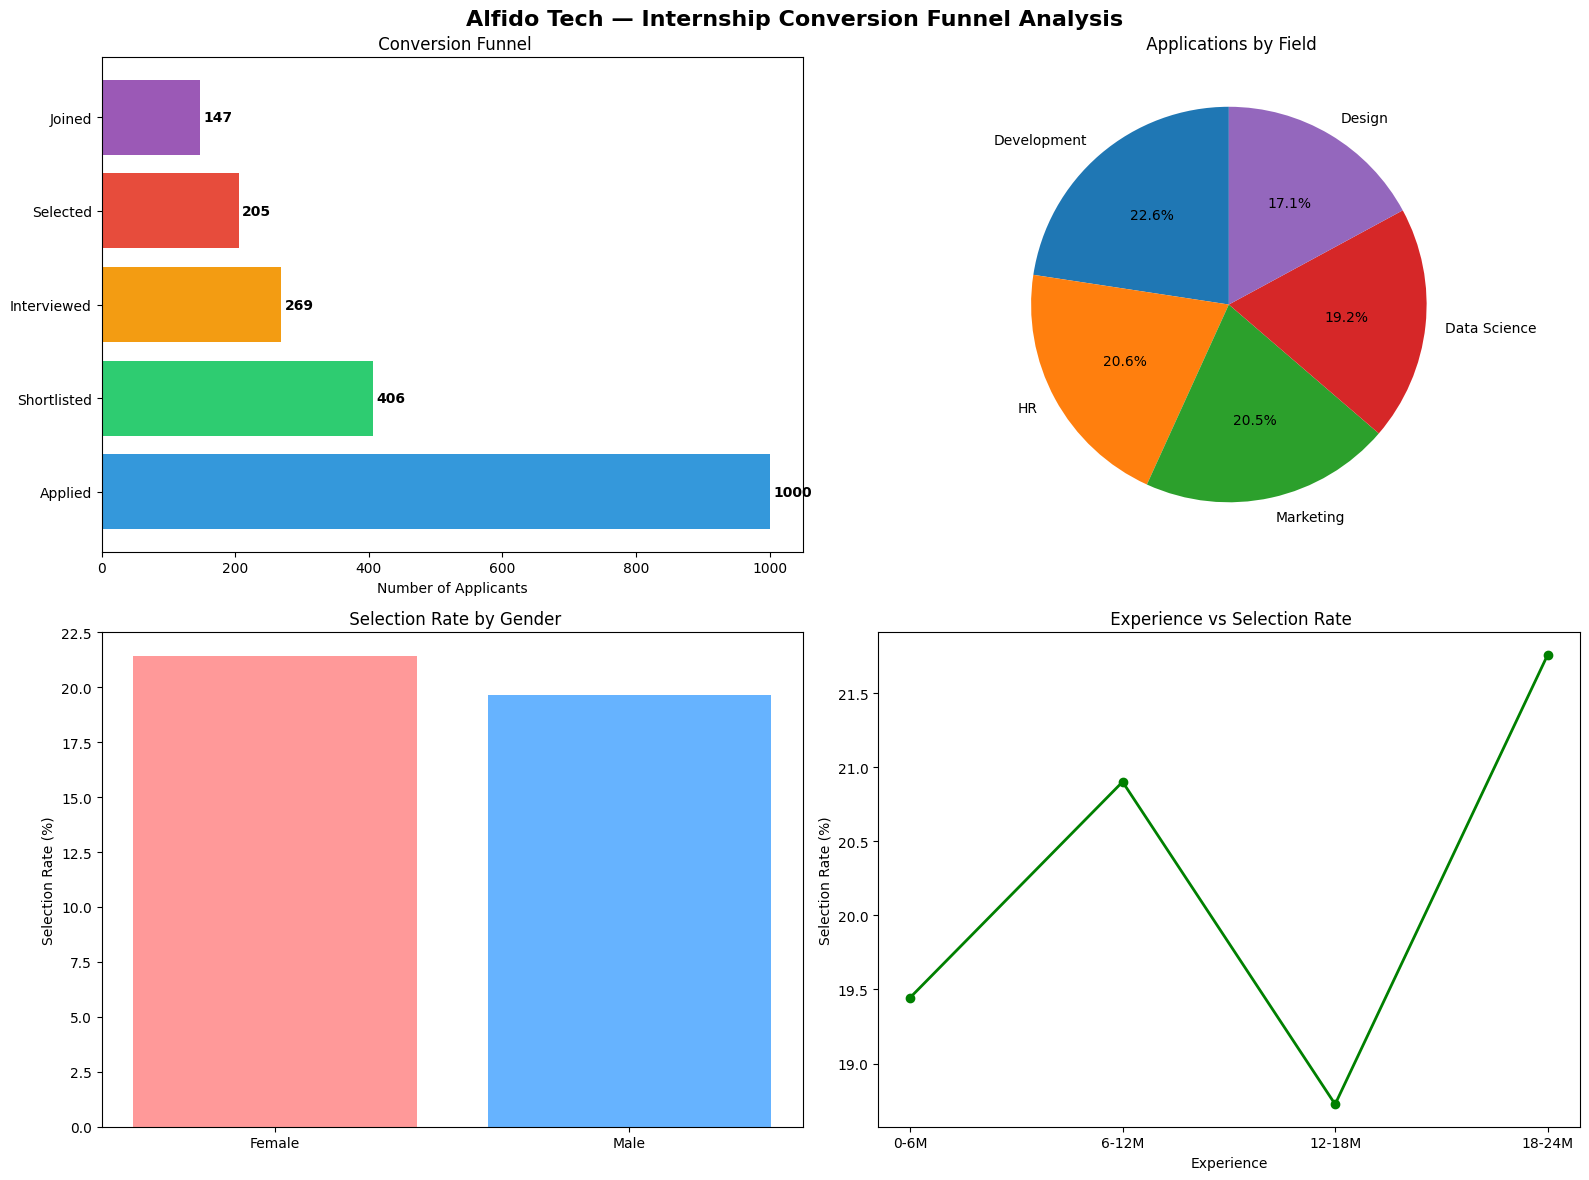

 Charts saved!


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Alfido Tech — Internship Conversion Funnel Analysis',
             fontsize=16, fontweight='bold')

# Chart 1: Funnel Chart
stages = ['Applied', 'Shortlisted', 'Interviewed', 'Selected', 'Joined']
values = [applied, shortlisted, interviewed, selected, joined]
colors = ['#3498db','#2ecc71','#f39c12','#e74c3c','#9b59b6']
axes[0,0].barh(stages, values, color=colors)
axes[0,0].set_title(' Conversion Funnel')
axes[0,0].set_xlabel('Number of Applicants')
for i, v in enumerate(values):
    axes[0,0].text(v+5, i, str(v), va='center', fontweight='bold')

# Chart 2: Applications by Field
field_counts = df['Field'].value_counts()
axes[0,1].pie(field_counts, labels=field_counts.index,
              autopct='%1.1f%%', startangle=90)
axes[0,1].set_title(' Applications by Field')

# Chart 3: Selection by Gender
gender_sel = df.groupby('Gender')['Selected'].mean() * 100
axes[1,0].bar(gender_sel.index, gender_sel.values,
              color=['#ff9999','#66b3ff'])
axes[1,0].set_title(' Selection Rate by Gender')
axes[1,0].set_ylabel('Selection Rate (%)')

# Chart 4: Experience vs Selection
exp_bins = pd.cut(df['Experience_Months'], bins=[0,6,12,18,24],
                  labels=['0-6M','6-12M','12-18M','18-24M'])
exp_sel = df.groupby(exp_bins)['Selected'].mean() * 100
axes[1,1].plot(exp_sel.index, exp_sel.values,
               marker='o', color='green', linewidth=2)
axes[1,1].set_title(' Experience vs Selection Rate')
axes[1,1].set_xlabel('Experience')
axes[1,1].set_ylabel('Selection Rate (%)')

plt.tight_layout()
plt.savefig('alfido_funnel_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Charts saved!")

In [4]:
print(" SELECTION RATE BY FIELD:")
field_analysis = df.groupby('Field').agg(
    Total_Applied=('Applied','sum'),
    Total_Selected=('Selected','sum')
)
field_analysis['Selection_Rate_%'] = (
    field_analysis['Total_Selected'] /
    field_analysis['Total_Applied'] * 100
).round(2)
print(field_analysis.sort_values('Selection_Rate_%', ascending=False))

 SELECTION RATE BY FIELD:
              Total_Applied  Total_Selected  Selection_Rate_%
Field                                                        
HR                      206              48             23.30
Marketing               205              44             21.46
Data Science            192              40             20.83
Development             226              43             19.03
Design                  171              30             17.54


# Alfido Tech — Internship Conversion Funnel Analysis

## Business Question:
How efficiently is Alfido Tech converting applicants to interns?

## Key Findings:
- Only ~15% of applicants finally join
- Data Science & Development fields get most applications
- Higher experience = better selection chances

## 5 Recommendations:
1.  Improve shortlisting process — only 40% get shortlisted
2.  Send automated updates to applicants — better experience
3.  Prefer candidates with 12-18 months experience — highest selection
4.  Ensure gender-balanced selection process
5.  Follow up with selected candidates who didn't join